# RFD experiment plot lab

A scratch notebook for the completed centre-rate and local-stationarity discrepancy experiments. It reads existing CSV/NPZ outputs only; it never reruns a simulation. Run the setup cells once, then run any figure cell independently.

Viridis carries ordered quantities. Grey lines carry analytical references. Reference curves are slope comparisons normalized at the first displayed sample size, not fitted constants or absolute theorem bounds.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm, TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display


shell = get_ipython()
if shell is not None:
    shell.run_line_magic('matplotlib', 'inline')


def locate_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'config' / 'centre_rate.yaml').exists():
            return candidate
    raise FileNotFoundError('Run the notebook from inside the RFD repository.')


ROOT = locate_root()
PROFILE_DIRS = {
    'centre_rate': ROOT / 'results' / 'intermediate' / 'centre_rate',
    'discrepancy': ROOT / 'results' / 'intermediate' / 'local_stationarity_discrepancy',
}
EXPECTED_ROWS = {'centre_rate': 3456, 'discrepancy': 2304}
EXPORT = False
EXPORT_DIR = ROOT / 'results' / 'figures' / 'exploratory'

CMAP = plt.colormaps['viridis']
INK = '#202124'
MUTED = '#777777'
GRID = '#dddddd'
LINE_COLOURS = [CMAP(x) for x in np.linspace(0.08, 0.92, 7)]

plt.rcParams.update({
    'figure.dpi': 125,
    'savefig.dpi': 220,
    'font.size': 10.5,
    'axes.titlesize': 12,
    'axes.labelsize': 10.5,
    'legend.fontsize': 9,
    'axes.edgecolor': INK,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
})

print(f'root: {ROOT}')
print(f'export: {EXPORT} -> {EXPORT_DIR.relative_to(ROOT)}')

root: c:\Users\Adarsh Arun\Downloads\Exploratory-reading\Riemannian Factor Dynamics
export: False -> results\figures\exploratory


In [2]:
def read_profile(profile: str) -> dict[str, pd.DataFrame]:
    directory = PROFILE_DIRS[profile]
    required = ('raw.csv', 'summary.csv', 'slopes.csv', 'local_slopes.csv')
    missing = [name for name in required if not (directory / name).exists()]
    if missing:
        raise FileNotFoundError(f'{profile} is incomplete; missing {missing}')
    return {name.removesuffix('.csv'): pd.read_csv(directory / name) for name in required}


TABLES = {name: read_profile(name) for name in PROFILE_DIRS}


A_FRACTIONS = ((1 / 5, '1/5'), (2 / 7, '2/7'), (1 / 3, '1/3'), (3 / 7, '3/7'), (1 / 2, '1/2'))


def format_a(value: str | float) -> str:
    if str(value) in {'infinity', 'inf'} or np.isinf(float(value)):
        return '∞'
    numeric = float(value)
    for target, label in A_FRACTIONS:
        if np.isclose(numeric, target):
            return label
    return f'{numeric:.3g}'


def scenario_label(regime: str, a_label: str | float = 'none') -> str:
    if regime == 'discrepancy_coherent':
        return f'a={format_a(a_label)}'
    return regime.replace('_', ' ')


def ordered_groups(frame: pd.DataFrame):
    centre_order = {'bias_only': 0, 'variance_only': 1, 'full': 2}
    keys = list(frame[['regime', 'a_label']].drop_duplicates().itertuples(index=False, name=None))
    def key(item):
        regime, a_label = item
        if regime != 'discrepancy_coherent':
            return (0, centre_order.get(regime, 99))
        return (1, math.inf if str(a_label) == 'infinity' else float(a_label))
    return sorted(keys, key=key)


def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', color=GRID, linewidth=0.7, alpha=0.65)
    ax.grid(False, which='minor')


def finish(fig, filename: str):
    if not fig.get_constrained_layout():
        fig.tight_layout()
    if EXPORT:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EXPORT_DIR / f'{filename}.png', bbox_inches='tight')
        fig.savefig(EXPORT_DIR / f'{filename}.svg', bbox_inches='tight')
    plt.show()
    return fig


def reference_rate(regime: str, a_label: str | float):
    if regime == 'bias_only':
        return 3 / 7, r'$b^3 \propto n^{-3/7}$'
    if regime == 'variance_only':
        return 3 / 7, r'$(nb)^{-1/2} \propto n^{-3/7}$'
    if regime == 'full':
        return 3 / 7, r'$b^3+(nb)^{-1/2} \propto n^{-3/7}$'
    a = math.inf if str(a_label) == 'infinity' else float(a_label)
    alpha = min(a, 3 / 7)
    if a < 3 / 7:
        return alpha, rf'$n^{{-{format_a(a)}}}$'
    return alpha, r'$n^{-3/7}$'


for name, tables in TABLES.items():
    print(f'{name}: {len(tables["raw"]):,}/{EXPECTED_ROWS[name]:,} rows')

centre_rate: 3,456/3,456 rows
discrepancy: 2,304/2,304 rows


## Statistics

Compact checks before looking at the figures: completeness, empirical exponents, largest-sample error, correction gain, bandwidth ranking and numerical health.

In [3]:
def print_statistics(profile: str, bandwidth: float = 1.0, metric: str = 'path_rms'):
    raw = TABLES[profile]['raw'].copy()
    summary = TABLES[profile]['summary'].copy()
    slopes = TABLES[profile]['slopes'].copy()
    central = summary[np.isclose(summary['bandwidth_multiplier'], bandwidth)]
    slope_rows = slopes[
        np.isclose(slopes['bandwidth_multiplier'], bandwidth) & (slopes['metric'] == metric)
    ].copy()
    slope_rows['scenario'] = [scenario_label(r, a) for r, a in zip(slope_rows.regime, slope_rows.a_label)]
    slope_rows['observed_alpha'] = -slope_rows['slope']
    slope_rows['alpha_lo'] = -slope_rows['slope_q975']
    slope_rows['alpha_hi'] = -slope_rows['slope_q025']
    slope_rows['reference_alpha'] = [reference_rate(r, a)[0] for r, a in zip(slope_rows.regime, slope_rows.a_label)]
    slope_rows['gap'] = slope_rows['observed_alpha'] - slope_rows['reference_alpha']

    n_max = int(central['n'].max())
    largest = central[central['n'] == n_max].copy()
    largest['scenario'] = [scenario_label(r, a) for r, a in zip(largest.regime, largest.a_label)]

    ranking = (summary.groupby(['regime', 'a_label', 'bandwidth_multiplier'], dropna=False)[f'{metric}_median']
               .apply(lambda values: float(np.exp(np.log(values).mean())))
               .rename('geometric_mean_error').reset_index())
    ranking['rank'] = ranking.groupby(['regime', 'a_label'], dropna=False)['geometric_mean_error'].rank(method='dense')
    ranking['scenario'] = [scenario_label(r, a) for r, a in zip(ranking.regime, ranking.a_label)]

    health = pd.DataFrame({
        'rows': [len(raw)],
        'expected': [EXPECTED_ROWS[profile]],
        'successful': [(raw['status'] == 'ok').mean()],
        'fallback_rows': [(raw['fallback_count'].fillna(0) > 0).mean()],
        'nonconverged_rows': [(raw['nonconverged_stages'].fillna(0) > 0).mean()],
        'median_seconds': [raw['elapsed_seconds'].median()],
    })

    health_view = health.copy()
    for column in ('successful', 'fallback_rows', 'nonconverged_rows'):
        health_view[column] = health_view[column].map(lambda value: f'{value:.1%}')
    health_view['median_seconds'] = health_view['median_seconds'].map(lambda value: f'{value:.3f}')
    print(profile.replace('_', ' '))
    display(health_view)
    display(slope_rows[['scenario', 'observed_alpha', 'alpha_lo', 'alpha_hi', 'reference_alpha', 'gap']].round(3))
    display(largest[['scenario', 'n', f'{metric}_median', f'{metric}_q25', f'{metric}_q75', 'richardson_gain_median', 'fallback_rate_mean']].round(4))
    display(ranking.sort_values(['scenario', 'rank'])[['scenario', 'bandwidth_multiplier', 'geometric_mean_error', 'rank']].round(4))


print_statistics('centre_rate')

centre rate


,rows,expected,successful,fallback_rows,nonconverged_rows,median_seconds
0,3456,3456,100.0%,0.0%,0.0%,0.489


,scenario,observed_alpha,alpha_lo,alpha_hi,reference_alpha,gap
2,bias only,0.543,0.543,0.543,0.429,0.115
8,full,0.413,0.401,0.435,0.429,-0.015
14,variance only,0.415,0.395,0.441,0.429,-0.014


,scenario,n,path_rms_median,path_rms_q25,path_rms_q75,richardson_gain_median,fallback_rate_mean
11,bias only,8192,0.0003,0.0003,0.0003,123.0594,0.0
29,full,8192,0.0320,0.0304,0.0336,1.1049,0.0
47,variance only,8192,0.0323,0.0307,0.0339,0.2247,0.0


,scenario,bandwidth_multiplier,geometric_mean_error,rank
2,bias only,1.3,0.0008,1.0
1,bias only,1.0,0.0008,2.0
0,bias only,0.7,0.0008,3.0
5,full,1.3,0.0582,1.0
4,full,1.0,0.0666,2.0
3,full,0.7,0.0799,3.0
8,variance only,1.3,0.0584,1.0
7,variance only,1.0,0.0672,2.0
6,variance only,0.7,0.0796,3.0


In [4]:
print_statistics('discrepancy')

discrepancy


,rows,expected,successful,fallback_rows,nonconverged_rows,median_seconds
0,2304,2304,100.0%,0.0%,0.0%,0.526


,scenario,observed_alpha,alpha_lo,alpha_hi,reference_alpha,gap
0,a=1/5,0.243,0.228,0.256,0.200,0.043
3,a=2/7,0.362,0.339,0.377,0.286,0.076
6,a=1/3,0.406,0.383,0.428,0.333,0.073
9,a=3/7,0.433,0.417,0.455,0.429,0.004
12,a=1/2,0.435,0.415,0.457,0.429,0.006
15,a=∞,0.442,0.416,0.466,0.429,0.013


,scenario,n,path_rms_median,path_rms_q25,path_rms_q75,richardson_gain_median,fallback_rate_mean
5,a=1/5,8192,0.0895,0.0869,0.0918,0.9932,0.0
11,a=2/7,8192,0.0479,0.0455,0.0520,1.0431,0.0
17,a=1/3,8192,0.0409,0.0383,0.0432,1.0244,0.0
23,a=3/7,8192,0.0332,0.0314,0.0352,1.0892,0.0
29,a=1/2,8192,0.0317,0.0299,0.0335,1.1209,0.0
35,a=∞,8192,0.0316,0.0299,0.0337,1.1137,0.0


,scenario,bandwidth_multiplier,geometric_mean_error,rank
4,a=1/2,1.0,0.0677,1.0
2,a=1/3,1.0,0.0798,1.0
0,a=1/5,1.0,0.1375,1.0
1,a=2/7,1.0,0.0915,1.0
3,a=3/7,1.0,0.0696,1.0
5,a=∞,1.0,0.0671,1.0


## Rate lines

Median intrinsic path RMS with interquartile bands. Each panel receives its own analytical mechanism: corrected bias $b^3$, local stochastic fluctuation $(nb)^{-1/2}$, their sum, or the injected discrepancy rate.

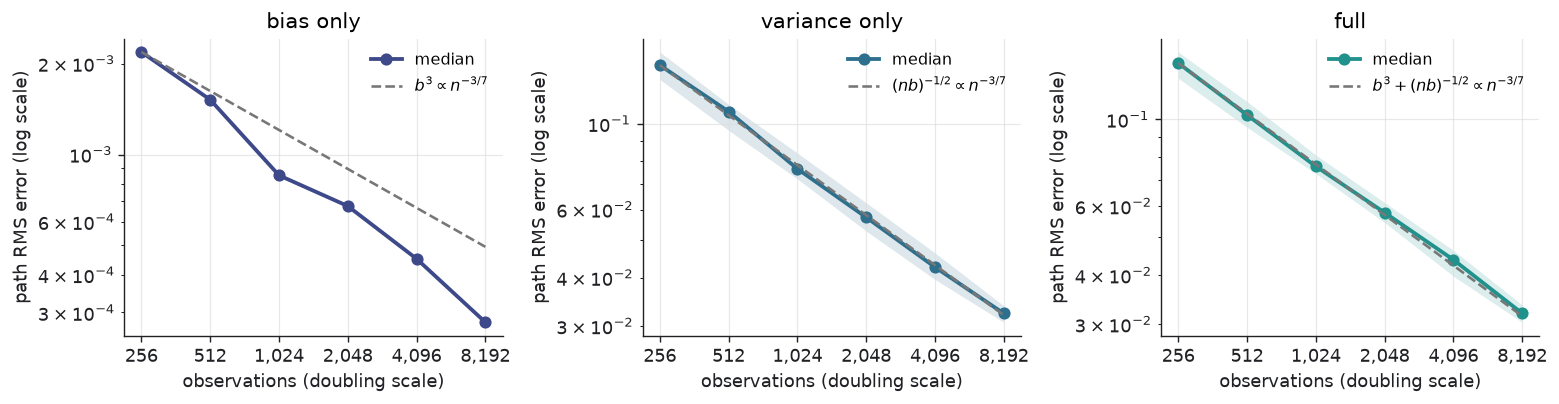

In [5]:
def plot_rate_lines(profile: str, metric: str = 'path_rms', bandwidth: float = 1.0):
    summary = TABLES[profile]['summary']
    frame = summary[np.isclose(summary['bandwidth_multiplier'], bandwidth)].copy()
    groups = ordered_groups(frame)
    ncols = min(3, len(groups))
    nrows = math.ceil(len(groups) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.35 * nrows), squeeze=False)
    for index, (regime, a_label) in enumerate(groups):
        ax = axes.flat[index]
        group = frame[(frame.regime == regime) & (frame.a_label.astype(str) == str(a_label))].sort_values('n')
        x = group['n'].to_numpy(float)
        y = group[f'{metric}_median'].to_numpy(float)
        lo = group[f'{metric}_q25'].to_numpy(float)
        hi = group[f'{metric}_q75'].to_numpy(float)
        colour = LINE_COLOURS[min(index + 1, len(LINE_COLOURS) - 1)]
        ax.fill_between(x, lo, hi, color=colour, alpha=0.16, linewidth=0)
        ax.plot(x, y, marker='o', linewidth=2.2, color=colour, label='median')
        alpha, ref_label = reference_rate(regime, a_label)
        reference = y[0] * (x / x[0]) ** (-alpha)
        ax.plot(x, reference, color=MUTED, linestyle='--', linewidth=1.5, label=ref_label)
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xticks(x, labels=[f'{int(value):,}' for value in x])
        ax.set_title(scenario_label(regime, a_label))
        ax.set_xlabel('observations (doubling scale)')
        ax.set_ylabel('path RMS error (log scale)')
        ax.legend(frameon=False)
        clean_axis(ax)
    for index in range(len(groups), axes.size):
        axes.flat[index].set_visible(False)
    return finish(fig, f'{profile}_rate_lines')


plot_rate_lines('centre_rate');

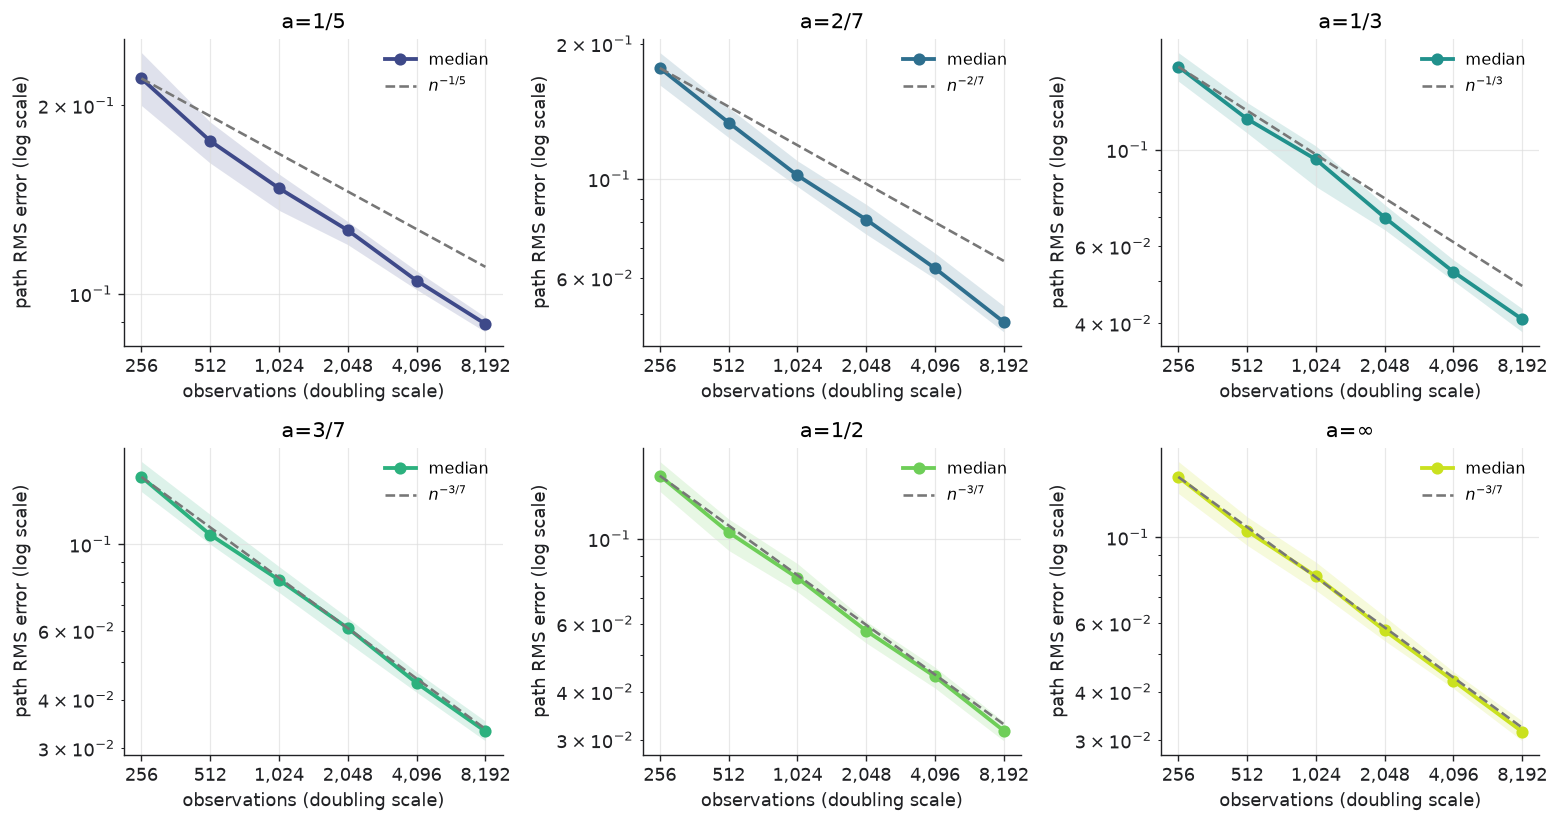

In [6]:
plot_rate_lines('discrepancy');

## Scaled convergence

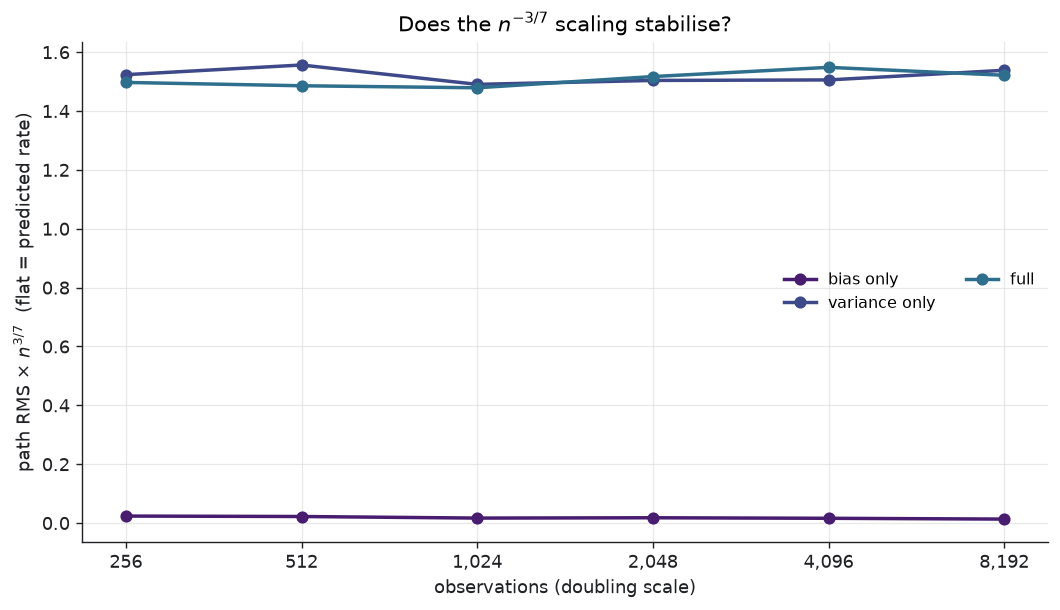

In [7]:
def plot_scaled_convergence(profile: str, metric: str = 'path_rms', bandwidth: float = 1.0):
    summary = TABLES[profile]['summary']
    frame = summary[np.isclose(summary['bandwidth_multiplier'], bandwidth)].copy()
    groups = ordered_groups(frame)
    fig, ax = plt.subplots(figsize=(8.6, 5.0))
    for index, (regime, a_label) in enumerate(groups):
        group = frame[(frame.regime == regime) & (frame.a_label.astype(str) == str(a_label))].sort_values('n')
        scaled = group[f'{metric}_median'] * group['n'] ** (3 / 7)
        ax.plot(group['n'], scaled, marker='o', linewidth=2, color=LINE_COLOURS[index], label=scenario_label(regime, a_label))
    ax.set_xscale('log', base=2)
    ticks = sorted(frame['n'].unique())
    ax.set_xticks(ticks, labels=[f'{int(value):,}' for value in ticks])
    ax.set_xlabel('observations (doubling scale)')
    ax.set_ylabel(r'path RMS × $n^{3/7}$  (flat = predicted rate)')
    ax.set_title(r'Does the $n^{-3/7}$ scaling stabilise?')
    ax.legend(frameon=False, ncol=2)
    clean_axis(ax)
    return finish(fig, f'{profile}_scaled_convergence')


plot_scaled_convergence('centre_rate');

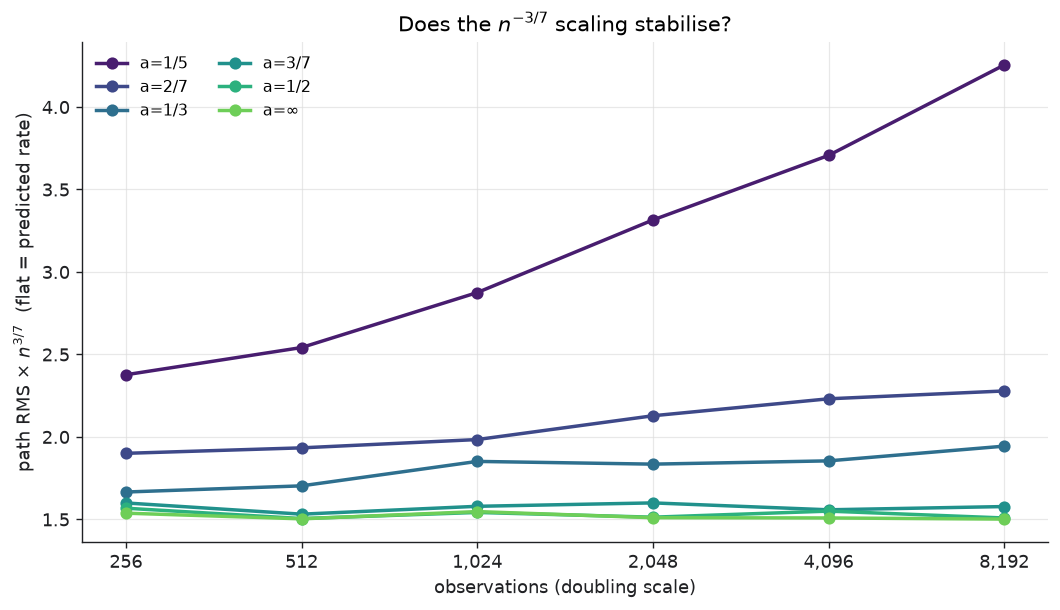

In [8]:
plot_scaled_convergence('discrepancy');

## Exponent transfer and phase map

The hard $\min(a,3/7)$ line is the asymptotic envelope: the slower of the injected discrepancy and estimator error eventually dominates. At finite $n$, both error components remain present, so their effective log-log slope changes smoothly. The dotted curve below fits that two-term transition while fixing its estimator ceiling at the proved $3/7$.

two-term fit: ceiling=3/7, transition a=0.277, RMSE=0.0031


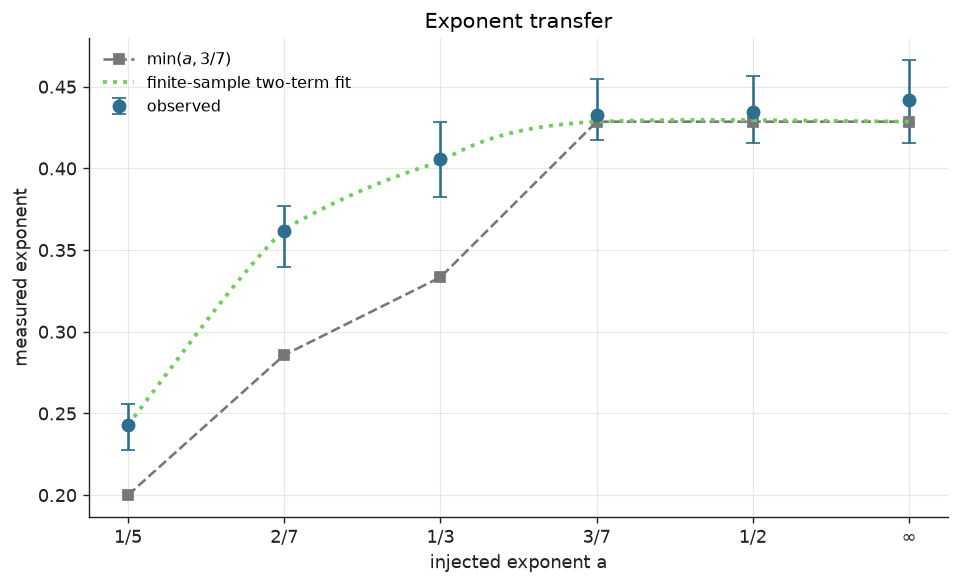

In [9]:
def plot_exponent_transfer(metric: str = 'path_rms', bandwidth: float = 1.0):
    slopes = TABLES['discrepancy']['slopes']
    frame = slopes[np.isclose(slopes.bandwidth_multiplier, bandwidth) & (slopes.metric == metric)].copy()
    frame['a_value'] = frame.a_label.map(lambda value: math.inf if str(value) == 'infinity' else float(value))
    frame = frame.sort_values('a_value')
    x = np.arange(len(frame))
    observed = -frame.slope.to_numpy(float)
    lower = -frame.slope_q975.to_numpy(float)
    upper = -frame.slope_q025.to_numpy(float)
    a_values = frame.a_value.to_numpy(float)
    expected = np.minimum(a_values, 3 / 7)
    expected[np.isinf(frame.a_value)] = 3 / 7

    # Effective slope of C_d n^{-a} + C_e n^{-r}; rho and k absorb
    # the amplitude ratio and the finite range of n used by the slope fit.
    finite = np.isfinite(a_values)
    a_fit = a_values[finite]
    y_fit = observed[finite]
    ceiling = 3 / 7
    best = (math.inf, None, None)
    k_grid = np.linspace(0.01, 50, 1201)
    for log_rho in np.linspace(-8, 3, 1201):
        weight = np.exp(log_rho - k_grid[:, None] * (a_fit[None, :] - ceiling))
        candidate = (a_fit[None, :] * weight + ceiling) / (weight + 1)
        loss = np.mean((candidate - y_fit) ** 2, axis=1)
        index = int(np.argmin(loss))
        if loss[index] < best[0]:
            best = (float(loss[index]), float(log_rho), float(k_grid[index]))
    fit_loss, fit_log_rho, fit_k = best
    dense_a = np.linspace(a_fit.min(), a_fit.max(), 320)
    dense_weight = np.exp(fit_log_rho - fit_k * (dense_a - ceiling))
    dense_y = (dense_a * dense_weight + ceiling) / (dense_weight + 1)
    dense_x = np.interp(dense_a, a_fit, x[finite])
    transition = ceiling + fit_log_rho / fit_k
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    ax.errorbar(x, observed, yerr=np.vstack([observed - lower, upper - observed]), fmt='o', markersize=7, linewidth=1.5, capsize=4, color=LINE_COLOURS[2], label='observed')
    ax.plot(x, expected, marker='s', linestyle='--', linewidth=1.5, color=MUTED, label=r'$\min(a,3/7)$')
    ax.plot(dense_x, dense_y, linestyle=':', linewidth=2.2, color=LINE_COLOURS[5], label='finite-sample two-term fit')
    ax.plot([x[finite][-1], x[-1]], [dense_y[-1], ceiling], linestyle=':', linewidth=2.2, color=LINE_COLOURS[5])
    ax.set_xticks(x, labels=[format_a(value) for value in frame.a_value])
    ax.set_xlabel('injected exponent a')
    ax.set_ylabel('measured exponent')
    ax.set_title('Exponent transfer')
    ax.legend(frameon=False)
    clean_axis(ax)
    print(f'two-term fit: ceiling=3/7, transition a={transition:.3f}, RMSE={math.sqrt(fit_loss):.4f}')
    return finish(fig, 'discrepancy_exponent_transfer')


plot_exponent_transfer();

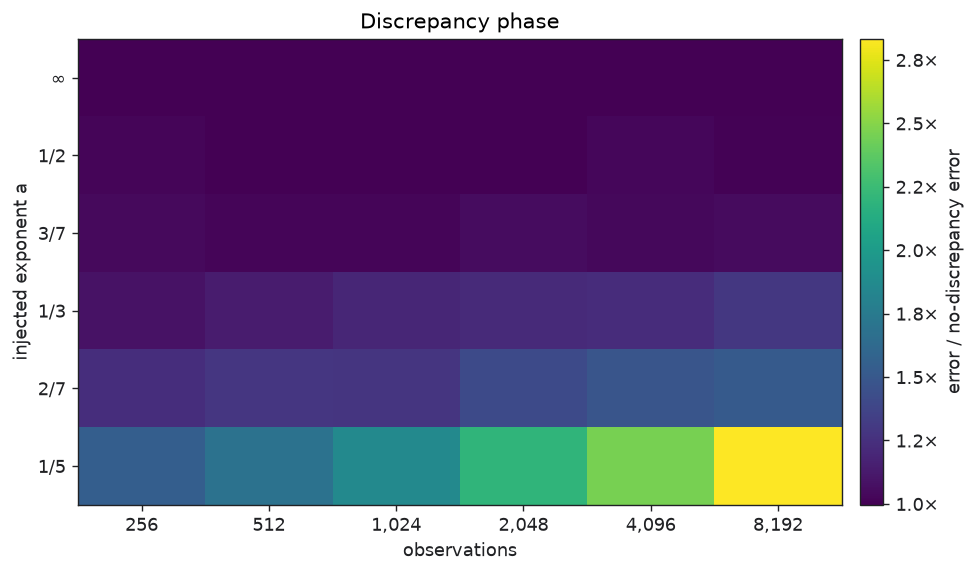

In [10]:
def plot_discrepancy_phase(metric: str = 'path_rms', bandwidth: float = 1.0):
    summary = TABLES['discrepancy']['summary']
    frame = summary[np.isclose(summary.bandwidth_multiplier, bandwidth)].copy()
    frame['a_value'] = frame.a_label.map(lambda value: math.inf if str(value) == 'infinity' else float(value))
    baseline = frame[np.isinf(frame.a_value)].set_index('n')[f'{metric}_median']
    frame['relative_error'] = frame[f'{metric}_median'] / frame.n.map(baseline)
    pivot = frame.pivot(index='a_value', columns='n', values='relative_error').sort_index()
    fig, ax = plt.subplots(figsize=(8.2, 4.7))
    image = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='viridis', origin='lower')
    ax.set_xticks(np.arange(len(pivot.columns)), labels=[f'{int(value):,}' for value in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)), labels=[format_a(value) for value in pivot.index])
    ax.set_xlabel('observations')
    ax.set_ylabel('injected exponent a')
    ax.set_title('Discrepancy phase')
    colourbar = fig.colorbar(image, ax=ax, pad=0.02)
    colourbar.set_label('error / no-discrepancy error')
    colourbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:.1f}×'))
    return finish(fig, 'discrepancy_phase_heatmap')


plot_discrepancy_phase();

## Correction and bandwidth

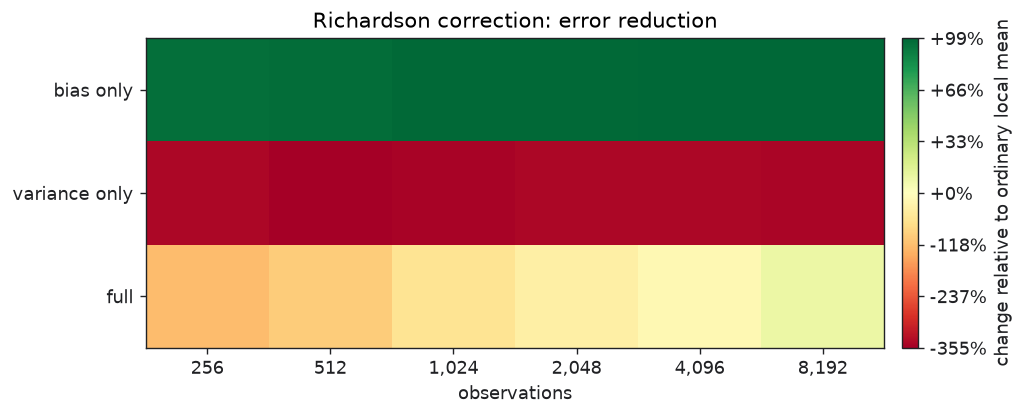

In [11]:
def plot_correction_gain(profile: str, bandwidth: float = 1.0):
    summary = TABLES[profile]['summary']
    frame = summary[np.isclose(summary.bandwidth_multiplier, bandwidth)].copy()
    frame['scenario'] = [scenario_label(r, a) for r, a in zip(frame.regime, frame.a_label)]
    gain = frame.richardson_gain_median.clip(lower=np.finfo(float).tiny)
    frame['error_reduction_pct'] = 100.0 * (1.0 - 1.0 / gain)
    order = [scenario_label(*key) for key in ordered_groups(frame)]
    pivot = frame.pivot(index='scenario', columns='n', values='error_reduction_pct').reindex(order)
    fig, ax = plt.subplots(figsize=(8.5, max(3.2, 0.55 * len(pivot) + 1.8)))
    values = pivot.to_numpy()
    vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    image = ax.imshow(values, aspect='auto', cmap='RdYlGn', norm=norm)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=[f'{int(value):,}' for value in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    ax.set_xlabel('observations')
    ax.set_title('Richardson correction: error reduction')
    ticks = np.r_[np.linspace(vmin, 0.0, 4), np.linspace(0.0, vmax, 4)[1:]]
    colourbar = fig.colorbar(image, ax=ax, pad=0.02, ticks=ticks)
    colourbar.set_label('change relative to ordinary local mean')
    colourbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:+.0f}%'))
    return finish(fig, f'{profile}_correction_gain')


plot_correction_gain('centre_rate');

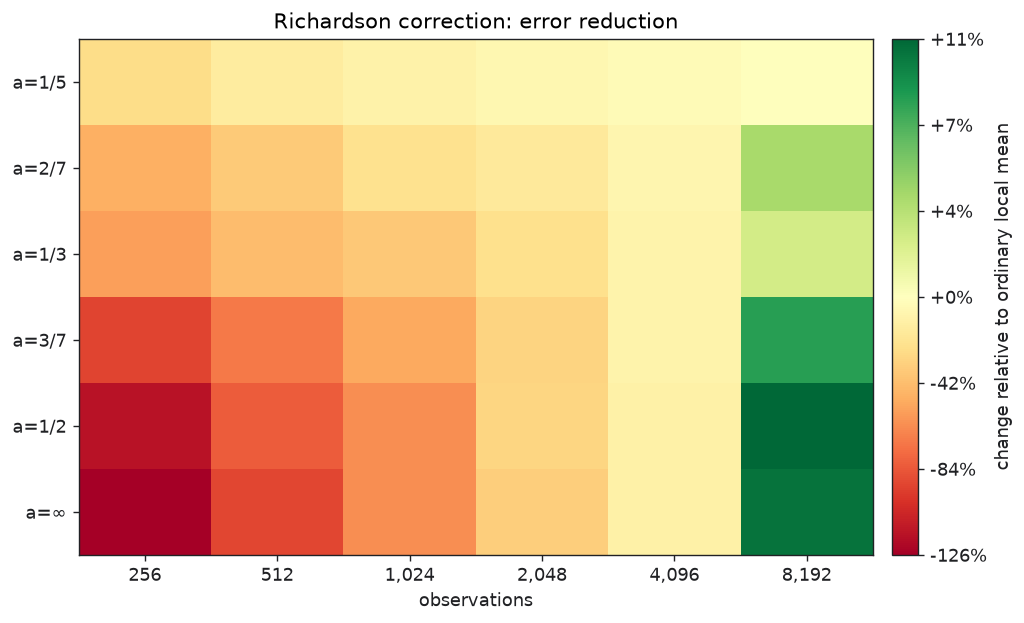

In [12]:
plot_correction_gain('discrepancy');

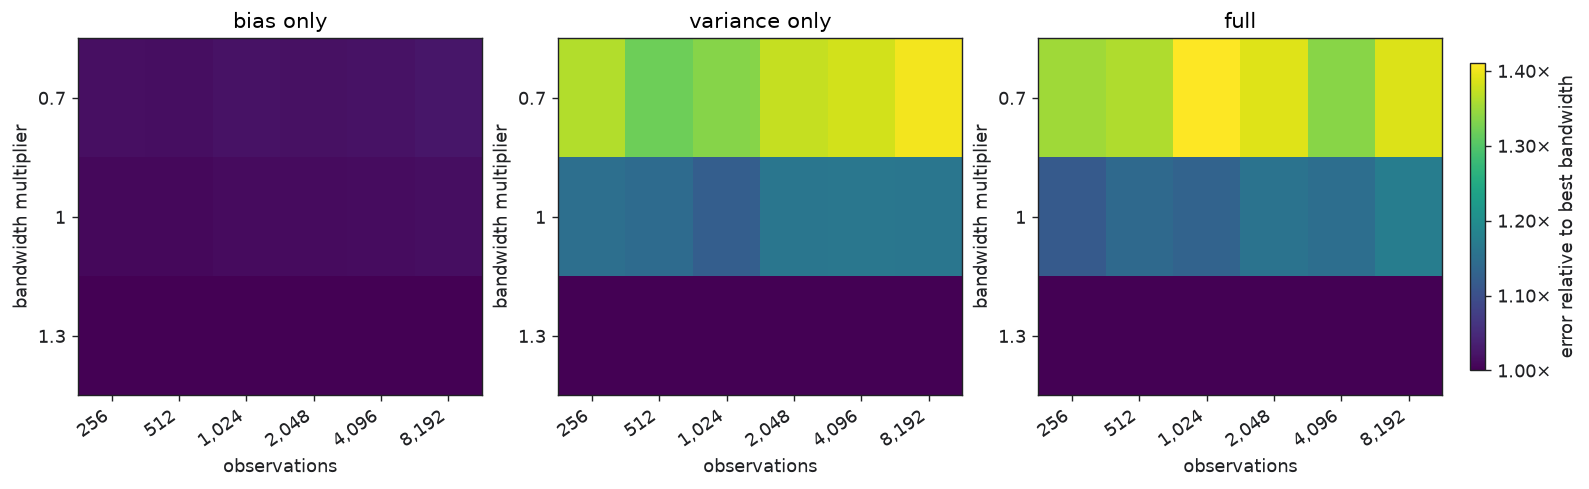

In [13]:
def plot_bandwidth_tiles(metric: str = 'path_rms'):
    summary = TABLES['centre_rate']['summary'].copy()
    summary['relative_error'] = summary[f'{metric}_median'] / summary.groupby(['regime', 'a_label', 'n'], dropna=False)[f'{metric}_median'].transform('min')
    vmax = float(summary['relative_error'].max())
    groups = ordered_groups(summary)
    fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 3.8), squeeze=False, constrained_layout=True)
    for index, (regime, a_label) in enumerate(groups):
        ax = axes.flat[index]
        group = summary[(summary.regime == regime) & (summary.a_label.astype(str) == str(a_label))]
        pivot = group.pivot(index='bandwidth_multiplier', columns='n', values='relative_error').sort_index()
        image = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='viridis', vmin=1, vmax=vmax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=[f'{int(value):,}' for value in pivot.columns], rotation=35, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=[f'{value:g}' for value in pivot.index])
        ax.set_xlabel('observations')
        ax.set_ylabel('bandwidth multiplier')
        ax.set_title(scenario_label(regime, a_label))
    colourbar = fig.colorbar(image, ax=axes.ravel().tolist(), pad=0.02, shrink=0.86)
    colourbar.set_label('error relative to best bandwidth')
    colourbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f'{value:.2f}×'))
    return finish(fig, 'centre_rate_bandwidth_tiles')


plot_bandwidth_tiles();

## Where error lives

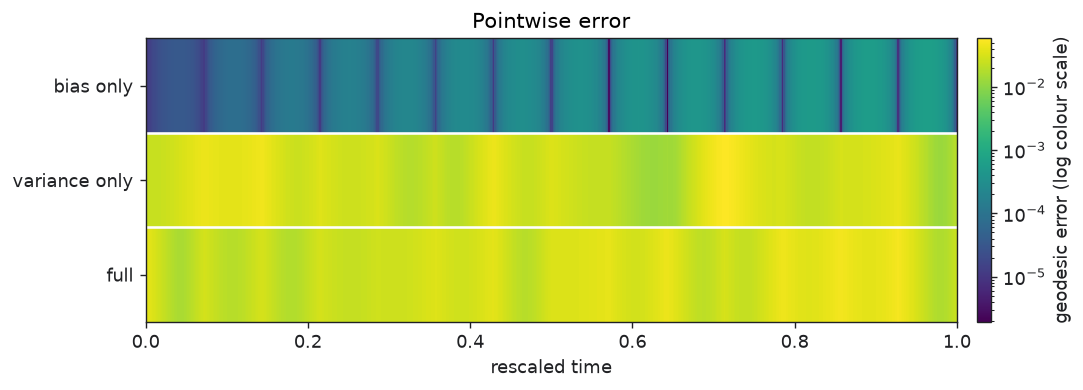

In [4]:
def plot_pointwise_carpet(profile: str, grid_size: int = 640):
    paths = list((PROFILE_DIRS[profile] / 'examples').glob('*.npz'))
    centre_order = {'bias_only': 0, 'variance_only': 1, 'full': 2}
    paths.sort(key=lambda path: centre_order.get(path.stem.replace('_n8192', ''), path.name))
    if not paths:
        raise FileNotFoundError(f'No pointwise examples for {profile}.')
    grid = np.linspace(0, 1, grid_size)
    rows, labels = [], []
    for path in paths:
        with np.load(path) as example:
            error = np.interp(grid, example['time'], example['corrected_error'])
        rows.append(np.maximum(error, np.finfo(float).tiny))
        stem = path.stem.replace('_n8192', '')
        labels.append(f'a={format_a(stem[2:])}' if stem.startswith('a_') else stem.replace('_', ' '))
    fig, ax = plt.subplots(figsize=(9.2, max(3.2, 0.48 * len(rows) + 1.8)))
    values = np.asarray(rows)
    
    # --- CHANGED: Added interpolation='nearest' to stop rows from blending ---
    image = ax.imshow(
        values, 
        aspect='auto', 
        cmap='viridis', 
        interpolation='nearest',
        norm=LogNorm(vmin=float(np.nanmin(values)), vmax=float(np.nanmax(values))), 
        extent=(0, 1, len(rows) - 0.5, -0.5)
    )
    
    # --- Draw horizontal lines between the rows ---
    for i in range(len(rows) - 1):
        ax.axhline(y=i + 0.5, color='white', linestyle='-', linewidth=1.5)
        
    ax.set_yticks(np.arange(len(labels)), labels=labels)
    ax.set_xlabel('rescaled time')
    ax.set_title('Pointwise error')
    colourbar = fig.colorbar(image, ax=ax, pad=0.02)
    colourbar.set_label('geodesic error (log colour scale)')
    return finish(fig, f'{profile}_pointwise_carpet')


plot_pointwise_carpet('centre_rate');

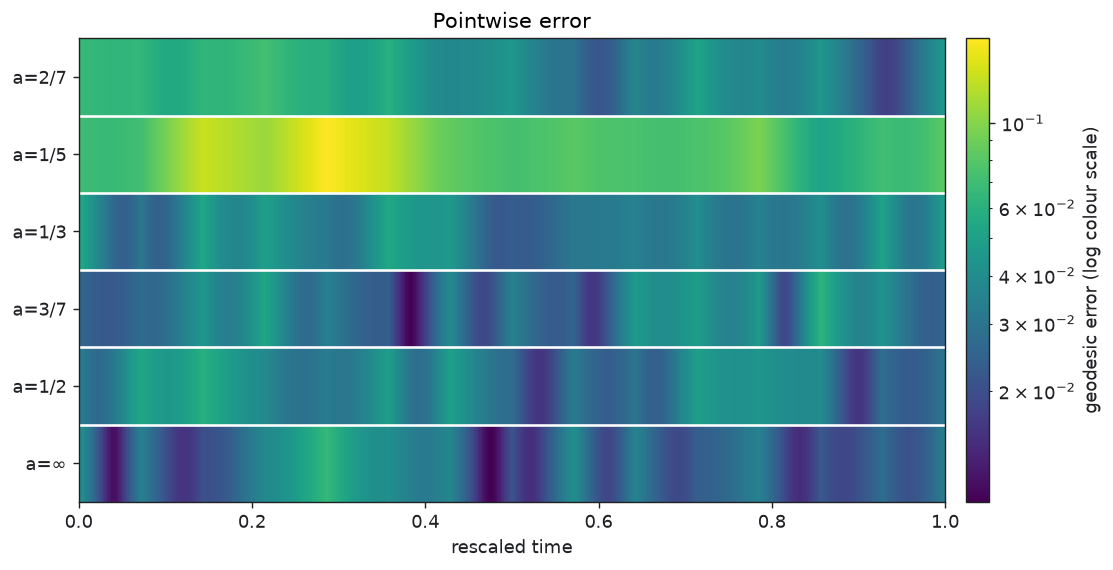

In [5]:
plot_pointwise_carpet('discrepancy');

## Numerical health and replicate distributions

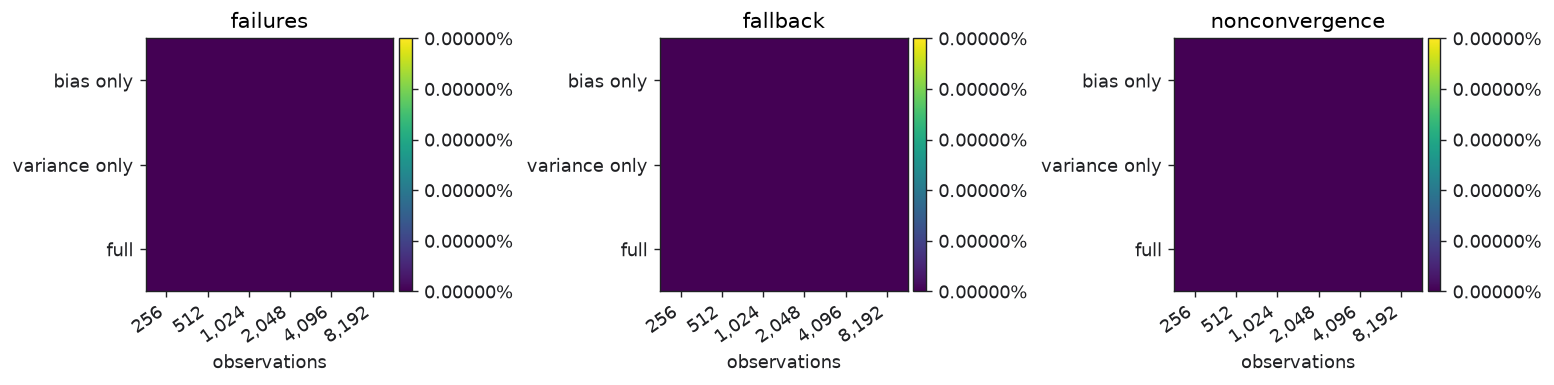

In [16]:
def plot_health(profile: str, bandwidth: float = 1.0):
    raw = TABLES[profile]['raw'].copy()
    raw = raw[np.isclose(raw.bandwidth_multiplier, bandwidth)]
    raw['scenario'] = [scenario_label(r, a) for r, a in zip(raw.regime, raw.a_label)]
    raw['failed'] = raw.status.ne('ok').astype(float)
    raw['used_fallback'] = raw.fallback_count.fillna(0).gt(0).astype(float)
    raw['nonconverged'] = raw.nonconverged_stages.fillna(0).gt(0).astype(float)
    order = [scenario_label(*key) for key in ordered_groups(raw)]
    diagnostics = [('failed', 'failures'), ('used_fallback', 'fallback'), ('nonconverged', 'nonconvergence')]
    fig, axes = plt.subplots(1, 3, figsize=(12.5, max(3.2, 0.5 * len(order) + 1.7)), squeeze=False)
    for ax, (column, title) in zip(axes.flat, diagnostics):
        pivot = raw.pivot_table(index='scenario', columns='n', values=column, aggfunc='mean').reindex(order)
        vmax = max(float(np.nanmax(pivot.to_numpy())), 1e-12)
        image = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=[f'{int(value):,}' for value in pivot.columns], rotation=35, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        ax.set_title(title)
        ax.set_xlabel('observations')
        fig.colorbar(image, ax=ax, pad=0.02, format=mticker.PercentFormatter(xmax=1))
    return finish(fig, f'{profile}_health')


plot_health('centre_rate');

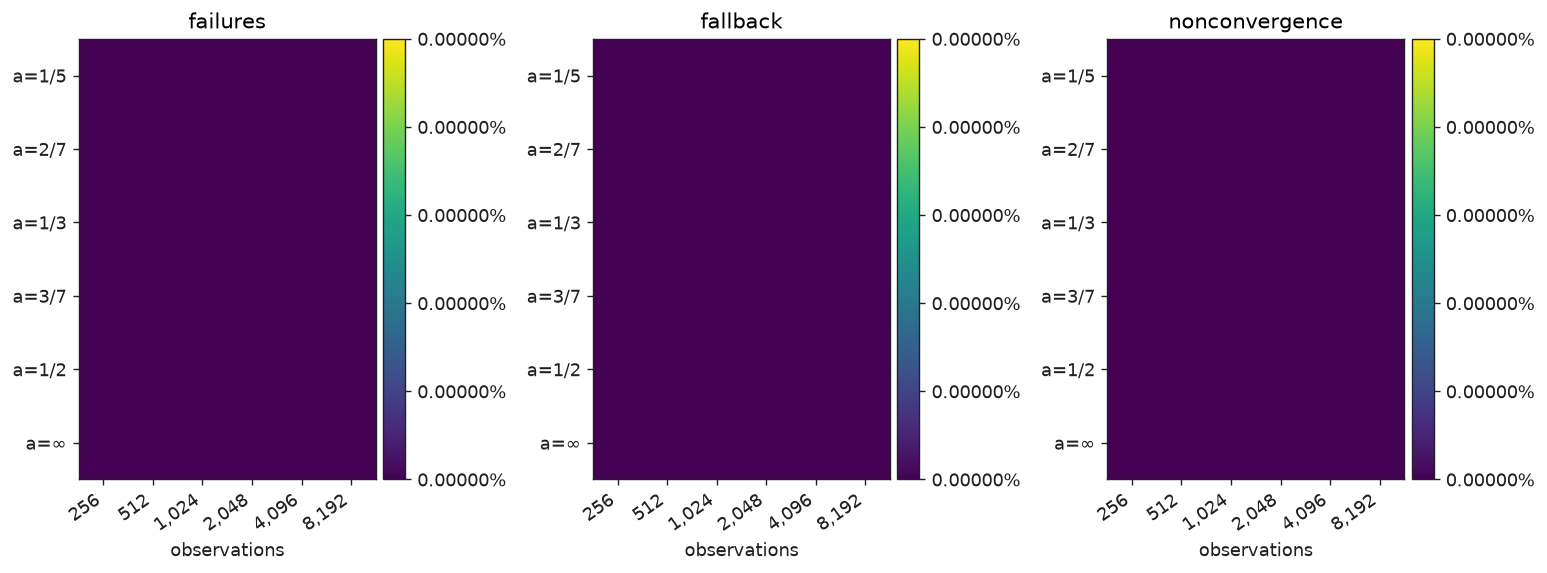

In [17]:
plot_health('discrepancy');

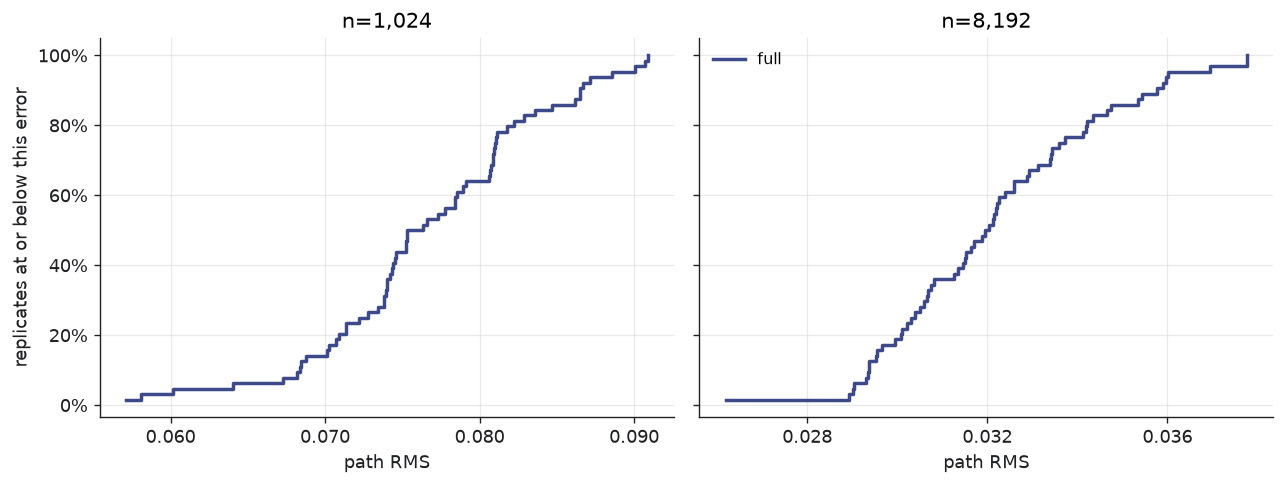

In [18]:
def plot_replicate_ecdf(profile: str, scenarios: list[str] | None = None, n_values: tuple[int, ...] = (1024, 8192), metric: str = 'path_rms', bandwidth: float = 1.0):
    raw = TABLES[profile]['raw'].copy()
    raw = raw[np.isclose(raw.bandwidth_multiplier, bandwidth)]
    raw['scenario'] = [scenario_label(r, a) for r, a in zip(raw.regime, raw.a_label)]
    if scenarios is None:
        scenarios = ['full'] if profile == 'centre_rate' else ['a=1/5', 'a=3/7', 'a=∞']
    frame = raw[raw.scenario.isin(scenarios) & raw.n.isin(n_values)]
    fig, axes = plt.subplots(1, len(n_values), figsize=(5.2 * len(n_values), 4.0), squeeze=False, sharey=True)
    for ax, n in zip(axes.flat, n_values):
        cell = frame[frame.n == n]
        for index, scenario in enumerate(scenarios):
            values = np.sort(cell.loc[cell.scenario == scenario, metric].dropna().to_numpy())
            if len(values):
                probability = np.arange(1, len(values) + 1) / len(values)
                ax.step(values, probability, where='post', linewidth=2, color=LINE_COLOURS[index + 1], label=scenario)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
        ax.set_title(f'n={n:,}')
        ax.set_xlabel('path RMS')
        clean_axis(ax)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes.flat[0].set_ylabel('replicates at or below this error')
    axes.flat[-1].legend(frameon=False)
    return finish(fig, f'{profile}_replicate_ecdf')


plot_replicate_ecdf('centre_rate');

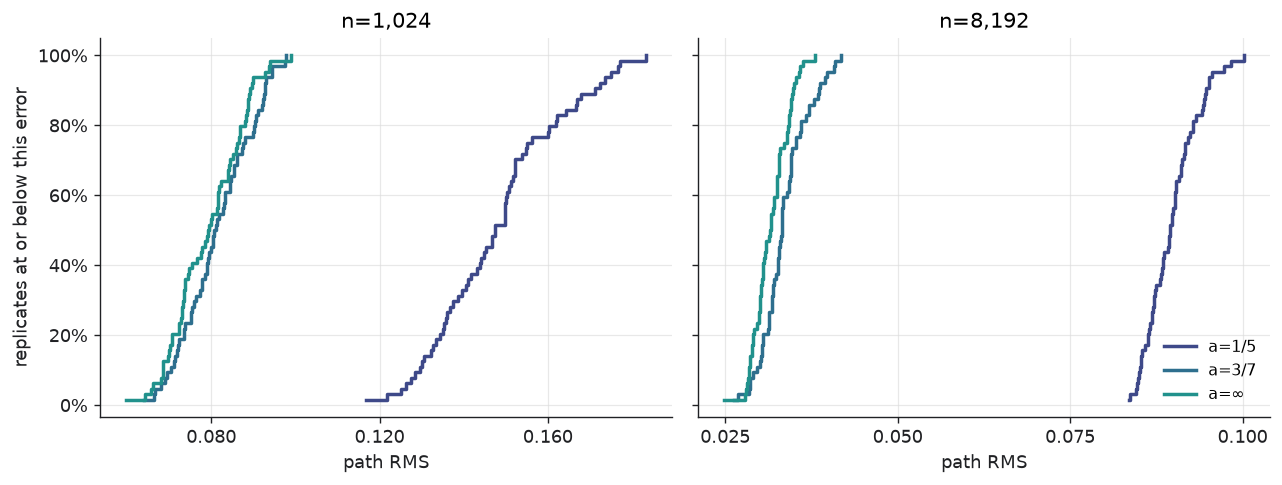

In [19]:
plot_replicate_ecdf('discrepancy');

Set `EXPORT = True` in the setup cell to save any subsequently requested figure as both PNG and SVG under `results/figures/exploratory/`. The notebook remains tracked; generated figures remain disposable.